In [1]:
from pathlib import Path
import pandas as pd

RAW = Path("../data/raw_datasets")
FILES = [
    "gossipcop_fake_en.csv",
    "gossipcop_real_en.csv",
    "train_en.tsv",
    "dev_en.tsv",
    "test_en.tsv",
]


def read_any(path: Path) -> pd.DataFrame:
    suf = path.suffix.lower()
    seps = ["\t"] if suf == ".tsv" else [",", "\t", ";"]
    last = None
    for enc in ("utf-8-sig", "utf-8", "cp1251"):
        for sep in seps:
            try:
                df = pd.read_csv(
                    path, sep=sep, encoding=enc,
                    engine="python", on_bad_lines="skip",
                )
                df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
                if df.shape[1] >= 2 or suf == ".tsv":
                    print(f"  read: sep={repr(sep)} enc={enc}")
                    return df
            except Exception as e:
                last = e
    raise RuntimeError(last)


def looks_like_label(name: str) -> bool:
    n = name.lower()
    return any(k in n for k in ("label", "veracity", "class", "fake", "target", "stance"))


for name in FILES:
    path = RAW / name
    print("\n" + "=" * 80)
    print(name)
    if not path.exists():
        print("  НЕТ ФАЙЛА:", path.resolve())
        continue
    print(f"  size: {path.stat().st_size/1e6:.2f} MB")

    df = read_any(path)
    print(f"  shape: {df.shape}")
    print(f"  columns ({len(df.columns)}): {list(df.columns)}")
    print("  dtypes:")
    print(df.dtypes.to_string())
    print("  nulls:")
    print(df.isna().sum().to_string())

    # все короткие/категориальные колонки
    for c in df.columns:
        nun = df[c].nunique(dropna=False)
        if nun <= 30 or looks_like_label(c):
            print(f"\n  value_counts [{c}] nunique={nun}:")
            print(df[c].astype(str).value_counts(dropna=False).head(20).to_string())

    # кусок текста
    text_cols = [c for c in df.columns if any(k in c.lower() for k in
                 ("title", "claim", "text", "headline", "news", "content"))]
    show = text_cols[:2] if text_cols else list(df.columns[:3])
    print("\n  head:")
    print(df[show].head(5).to_string(index=False))


gossipcop_fake_en.csv
  size: 12.54 MB
  read: sep=',' enc=utf-8-sig
  shape: (5323, 4)
  columns (4): ['id', 'news_url', 'title', 'tweet_ids']
  dtypes:
id           str
news_url     str
title        str
tweet_ids    str
  nulls:
id             0
news_url     256
title          0
tweet_ids    188

  head:
                                                                                                                                                           news_url                                                                                              title
                                                                 www.dailymail.co.uk/tvshowbiz/article-5874213/Did-Miley-Cyrus-Liam-Hemsworth-secretly-married.html                                           Did Miley Cyrus and Liam Hemsworth secretly get married?
                                                              hollywoodlife.com/2018/05/05/paris-jackson-cara-delevingne-matching-outfits-night-out-nyc-dating-pic/ P

Ячейка 1. Пути

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path("../data/raw_datasets")
PREP = Path("../data/prepared_datasets")
PREP.mkdir(parents=True, exist_ok=True)
SEED = 42

Ячейка 2. Хелперы

In [3]:
def pack(text, label, source):
    out = pd.DataFrame({
        "text": text,
        "label": label,
        "source": source,
        "orig_lang": "en",
    })
    out["text"] = out["text"].astype(str).str.strip()
    out = out[out["text"].ne("") & ~out["text"].str.lower().eq("nan")]
    out["label"] = out["label"].astype(int)
    return out.reset_index(drop=True)

Ячейка 3. GossipCop

In [4]:
fake = pd.read_csv(RAW / "gossipcop_fake_en.csv", engine="python", on_bad_lines="skip")
real = pd.read_csv(RAW / "gossipcop_real_en.csv", engine="python", on_bad_lines="skip")

g_fake = pack(fake["title"], 1, "gossipcop")
g_real = pack(real["title"], 0, "gossipcop")
g_real = g_real.sample(n=min(len(g_fake), len(g_real)), random_state=SEED)

print("gossip fake:", len(g_fake), "real (sampled):", len(g_real))

gossip fake: 5323 real (sampled): 5323


Ячейка 4. PUBHEALTH

In [5]:
LABEL_MAP = {"true": 0, "false": 1, "mixture": 1}
ph_parts = []

for fname, src in [
    ("train_en.tsv", "pubhealth_train"),
    ("dev_en.tsv", "pubhealth_dev"),
    ("test_en.tsv", "pubhealth_test"),
]:
    df = pd.read_csv(RAW / fname, sep="\t", engine="python", on_bad_lines="skip")
    lab = df["label"].astype(str).str.lower().str.strip().map(LABEL_MAP)
    ok = lab.notna() & df["claim"].notna()
    print(fname, "взяли", int(ok.sum()), "/", len(df), "выбросили", int((~ok).sum()))
    ph_parts.append(pack(df.loc[ok, "claim"], lab.loc[ok], src))

ph = pd.concat(ph_parts, ignore_index=True)
print("pubhealth всего:", len(ph), "fake", int((ph.label == 1).sum()), "real", int((ph.label == 0).sum()))

train_en.tsv взяли 9513 / 9832 выбросили 319
dev_en.tsv взяли 1173 / 1218 выбросили 45
test_en.tsv взяли 1188 / 1235 выбросили 47
pubhealth всего: 11874 fake 5568 real 6306


Ячейка 4b. Onion / HuffPost

In [6]:
sarc_path = RAW / "Sarcasm_Headlines_Dataset_v2_en.json"
sarc = pd.read_json(sarc_path, lines=True)
# если упадёт — попробуйте без lines=True
print("sarcasm cols:", list(sarc.columns), "rows:", len(sarc))
print(sarc["is_sarcastic"].value_counts())

onion = pack(sarc["headline"], sarc["is_sarcastic"].astype(int), "onion_huffpost")
print("onion/huff:", len(onion), "fake", int((onion.label==1).sum()), "real", int((onion.label==0).sum()))

sarcasm cols: ['is_sarcastic', 'headline', 'article_link'] rows: 28619
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64
onion/huff: 28619 fake 13634 real 14985


Ячейка 5. Склейка только EN

In [7]:
en = pd.concat([g_fake, g_real, ph, onion], ignore_index=True)
en = en.drop_duplicates(subset=["text"]).reset_index(drop=True)

by = (
    en.groupby("source")["label"]
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"})
)
for c in ("real", "fake"):
    if c not in by.columns:
        by[c] = 0
by["total"] = by["real"] + by["fake"]
by.loc["ALL"] = by.sum()

print(by)
print("\nИТОГО EN:", len(en))
print("правда (0):", int((en.label == 0).sum()))
print("фейк  (1):", int((en.label == 1).sum()))

label             real   fake  total
source                              
gossipcop         5173   4896  10069
onion_huffpost   14951  13552  28503
pubhealth_dev      629    544   1173
pubhealth_test     599    589   1188
pubhealth_train   5078   4435   9513
ALL              26430  24016  50446

ИТОГО EN: 50446
правда (0): 26430
фейк  (1): 24016


Ячейка 6. Картинка

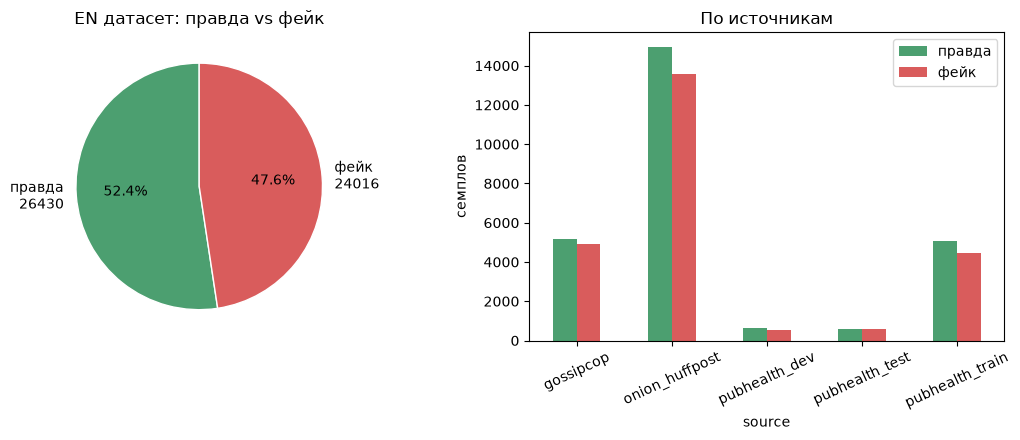

In [8]:
n_real = int((en.label == 0).sum())
n_fake = int((en.label == 1).sum())

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].pie(
    [n_real, n_fake],
    labels=[f"правда\n{n_real}", f"фейк\n{n_fake}"],
    autopct="%1.1f%%",
    colors=["#4C9F70", "#D95C5C"],
    startangle=90,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
ax[0].set_title("EN датасет: правда vs фейк")

by.drop(index="ALL")[["real", "fake"]].plot(
    kind="bar", ax=ax[1], color=["#4C9F70", "#D95C5C"], rot=25
)
ax[1].set_title("По источникам")
ax[1].set_ylabel("семплов")
ax[1].legend(["правда", "фейк"])
plt.tight_layout()
fig.savefig(PREP / "en_eda.png", dpi=150)
plt.show()

Ячейка 7. Сохранение

In [9]:
out = PREP / "en_dataset.csv"
en.to_csv(out, index=False)
print("сохранено:", out.resolve())
print("размер MB:", round(out.stat().st_size / 1e6, 3))

сохранено: C:\GitHub\tg-vm-fake-detector\data\prepared_datasets\en_dataset.csv
размер MB: 4.585
